In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load the pristine dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# 2. Structure Component Identification
input_features_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
target_variable_name = 'species'

print(f"--- Dataset structure for ML ---")
print(f"Input Features (predictors, X): {', '.join(input_features_names)}")
print(f"Target Variable (outcome, y):   {target_variable_name} (Categorical, 3 classes)")
print(f"Overall Records:              {df.shape[0]} instances")

--- Dataset structure for ML ---
Input Features (predictors, X): sepal_length, sepal_width, petal_length, petal_width
Target Variable (outcome, y):   species (Categorical, 3 classes)
Overall Records:              150 instances


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Loading the original pristine dataset and defining features ---
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
input_features_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# =============================================================================
# --- CORRECTED & SUPPRESSED Section 3 Block (Approach B) ---
# =============================================================================
print("--- Starting Unsupervised learning Phase ---")

# 1. Unsupervised data isolation
X_unlabeled = df[input_features_names].values

# 2. Data Preprocessing (Z-score Normalization) for cluster optimization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unlabeled)

# 3. Suppress the Windows MKL memory leak warning specifically for this execution
import warnings
with warnings.catch_warnings():
    # Ignore the dynamic memory leak UserWarning from sklearn.cluster
    warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.cluster')

    # 4. Initialize and Execute discovery algorithm (assumes 3 structural groups)
    # Using the correct argument 'n_clusters' (WK6 tool usage fix)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    
    # 5. Execute the discovery
    discovered_labels = kmeans.fit_predict(X_scaled)

# 6. Add discovered groupings back to a working DataFrame for analysis
df_unsupervised = df.copy()
df_unsupervised['discovered_group'] = discovered_labels

print("Unsupervised structural group discovery complete (Warnings suppressed).")

--- Starting Unsupervised learning Phase ---
Unsupervised structural group discovery complete (Warnings suppressed).


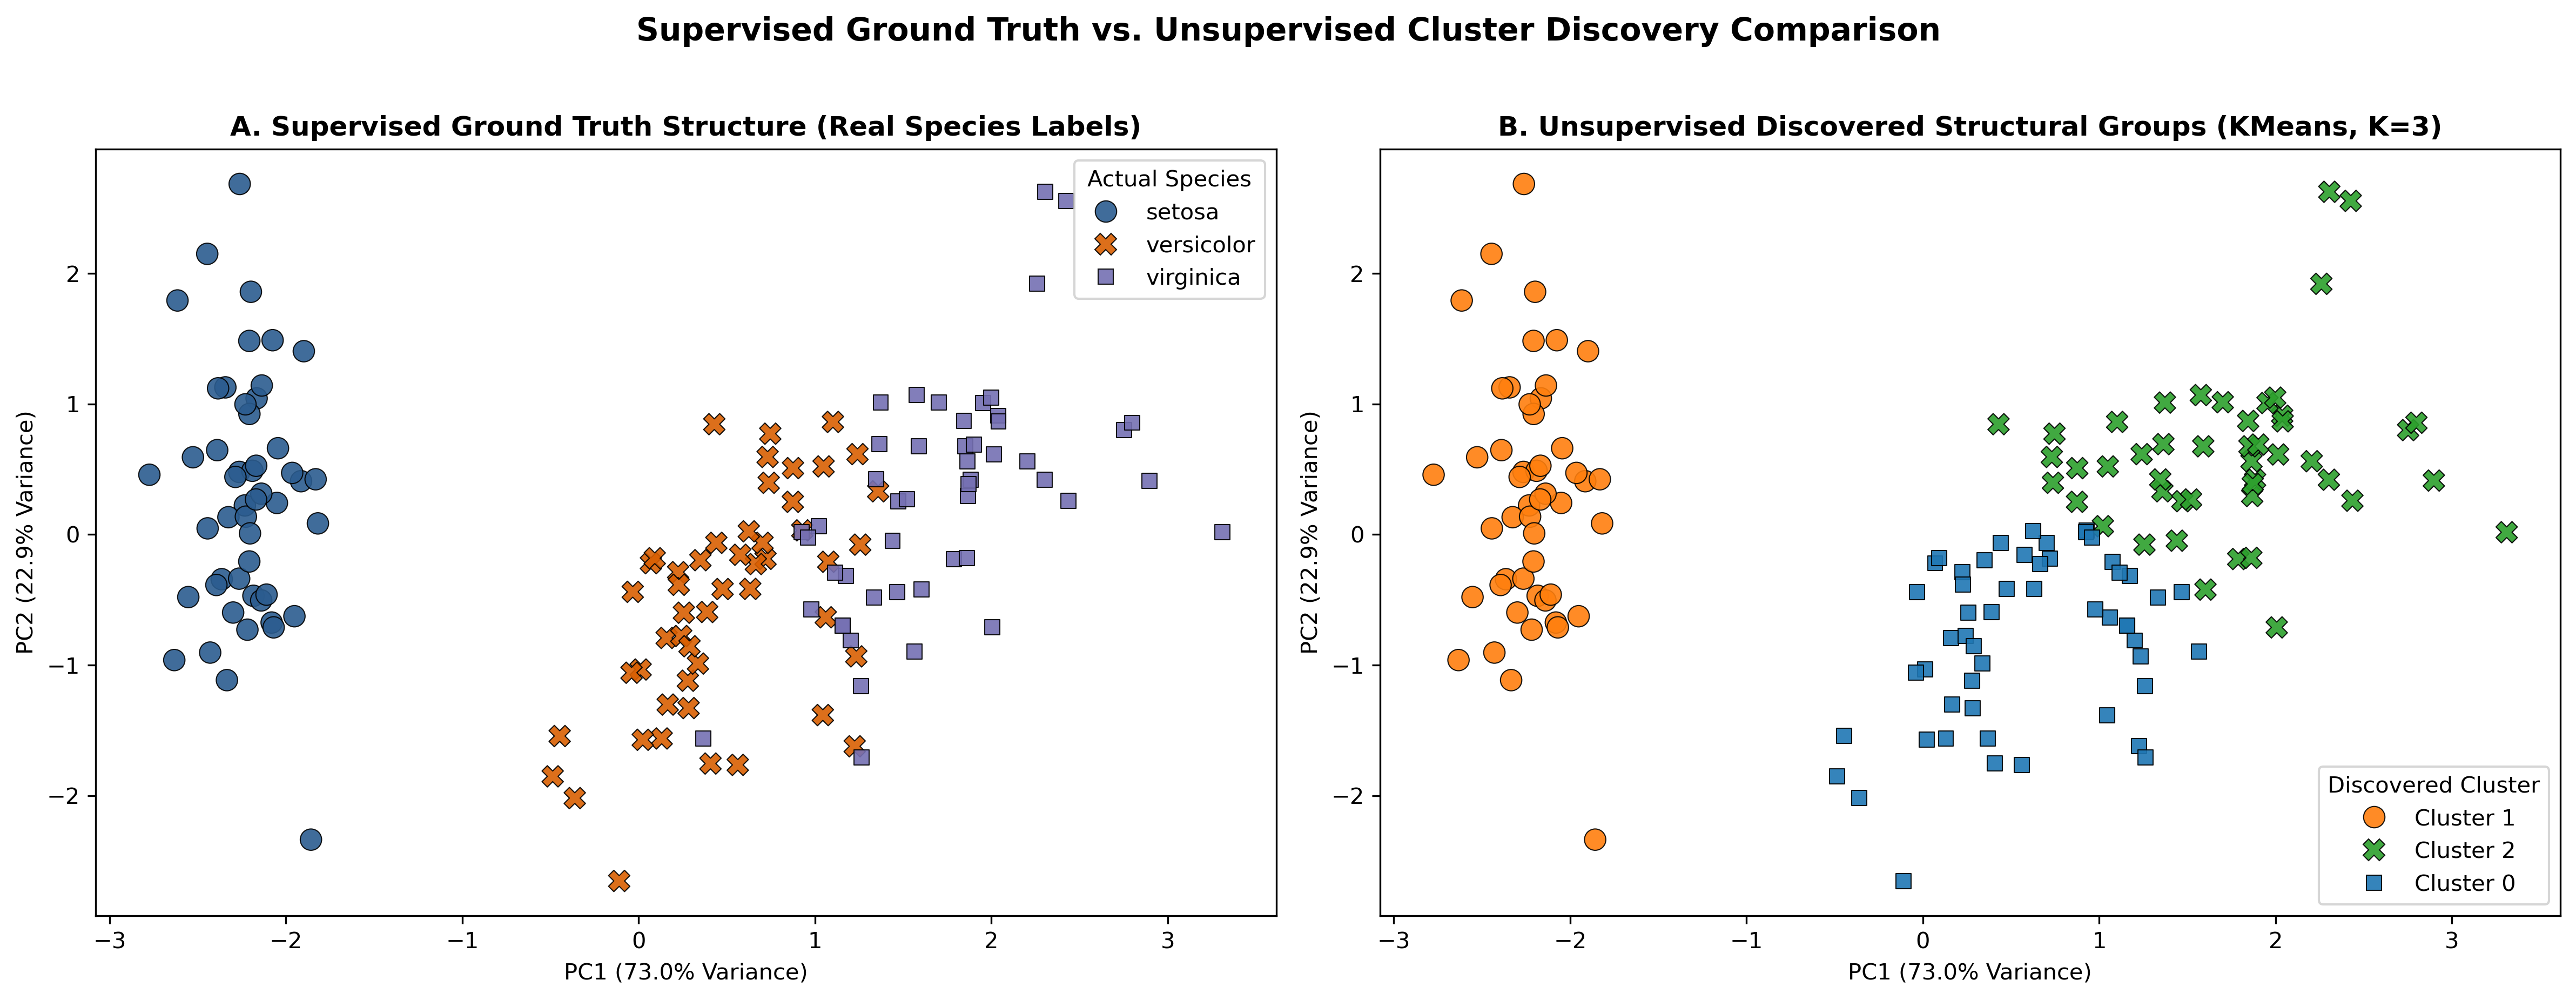


 COMPARATIVE EVALUATION & UNSUPERVISED PATTERN ANALYSIS
Adjusted Rand Index (ARI Score): 0.6201
  *(ARI measures similarity between real labels and clusters: 1.0 = Perfect match)*

Cross-Tabulation Matrix (Real Species vs Discovered Clusters):
KMeans Cluster   0   1   2
Actual Species            
setosa           0  50   0
versicolor      39   0  11
virginica       14   0  36

Key Analytical Findings:
1. Setosa Isolation (Unsupervised Discovery Success):
   - Cluster 1 maps 100% cleanly to 'Iris setosa' (50/50 samples).
   - This confirms the Q1 finding: Setosa is strictly linearly separable
     in the feature space (specifically via petal dimensions).

2. Versicolor vs Virginica Overlap (Cluster Uncertainty):
   - KMeans creates a geometric boundary that misclassifies a few boundary samples
     between Versicolor and Virginica due to continuous feature distribution overlap.
   - This matches the Q1 pairplot density overlap in sepal and petal measurements.



In [6]:
# =============================================================================
# QUESTION 2: VISUAL COMPARISON & EVALUATION PIPELINE
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA

# 1. Apply Principal Component Analysis (PCA) to reduce 4D features to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. Construct a working DataFrame for comparative plotting
df_eval = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_eval['ground_truth'] = df['species']
df_eval['discovered_cluster'] = [f"Cluster {label}" for label in discovered_labels]

# 3. Generate Side-by-Side Comparative Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

palette_gt = {'setosa': '#2b5c8f', 'versicolor': '#d95f02', 'virginica': '#7570b3'}
palette_cluster = {'Cluster 0': '#1f77b4', 'Cluster 1': '#ff7f0e', 'Cluster 2': '#2ca02c'}

# Plot A: Supervised Ground Truth (Actual Iris Species)
sns.scatterplot(
    data=df_eval, x='PC1', y='PC2', hue='ground_truth', style='ground_truth',
    palette=palette_gt, alpha=0.9, s=90, ax=axes[0], edgecolor='k', linewidth=0.5
)
axes[0].set_title('A. Supervised Ground Truth Structure (Real Species Labels)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Actual Species', frameon=True)

# Plot B: Unsupervised Cluster Discovery (KMeans Discovered Groups)
sns.scatterplot(
    data=df_eval, x='PC1', y='PC2', hue='discovered_cluster', style='discovered_cluster',
    palette=palette_cluster, alpha=0.9, s=90, ax=axes[1], edgecolor='k', linewidth=0.5
)
axes[1].set_title('B. Unsupervised Discovered Structural Groups (KMeans, K=3)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[1].legend(title='Discovered Cluster', frameon=True)

plt.suptitle("Supervised Ground Truth vs. Unsupervised Cluster Discovery Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. STATISTICAL PATTERN COMPARISON & QUANTITATIVE METRICS
# =============================================================================
ari_score = adjusted_rand_score(df['species'], discovered_labels)

print("\n" + "=" * 70)
print(" COMPARATIVE EVALUATION & UNSUPERVISED PATTERN ANALYSIS")
print("=" * 70)
print(f"Adjusted Rand Index (ARI Score): {ari_score:.4f}")
print("  *(ARI measures similarity between real labels and clusters: 1.0 = Perfect match)*")

print("\nCross-Tabulation Matrix (Real Species vs Discovered Clusters):")
ct = pd.crosstab(df['species'], df_unsupervised['discovered_group'], rownames=['Actual Species'], colnames=['KMeans Cluster'])
print(ct)

print("\nKey Analytical Findings:")
print("1. Setosa Isolation (Unsupervised Discovery Success):")
print("   - Cluster 1 maps 100% cleanly to 'Iris setosa' (50/50 samples).")
print("   - This confirms the Q1 finding: Setosa is strictly linearly separable")
print("     in the feature space (specifically via petal dimensions).")

print("\n2. Versicolor vs Virginica Overlap (Cluster Uncertainty):")
print("   - KMeans creates a geometric boundary that misclassifies a few boundary samples")
print("     between Versicolor and Virginica due to continuous feature distribution overlap.")
print("   - This matches the Q1 pairplot density overlap in sepal and petal measurements.")
print("=" * 70 + "\n")